In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8')

df = pd.read_csv('../data/raw/creditcard.csv')
print(f"Shape: {df.shape}")
print (f"Info: {df.info()}")
print(f"Columns: {list(df.columns)}")

Shape: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

=== CLASS DISTRIBUTION ===
Legitimate: 284,315  (99.827%)
Fraud:      492  (0.173%)
Imbalance ratio: 578:1


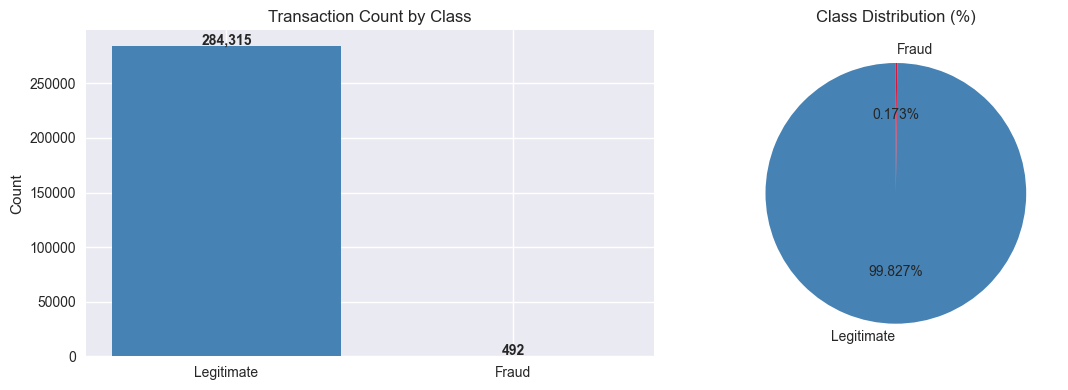

In [3]:
fraud_counts = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print("=== CLASS DISTRIBUTION ===")
print(f"Legitimate: {fraud_counts[0]:,}  ({fraud_pct[0]:.3f}%)")
print(f"Fraud:      {fraud_counts[1]:,}  ({fraud_pct[1]:.3f}%)")
print(f"Imbalance ratio: {fraud_counts[0]/fraud_counts[1]:.0f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values, 
            color=['steelblue', 'crimson'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            colors=['steelblue', 'crimson'], autopct='%1.3f%%', startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.savefig('../reports/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

=== AMOUNT STATISTICS ===
            count     mean      std    min    25%     50%      75%        max
Class                                                                        
0     284315.0000  88.2900 250.1100 0.0000 5.6500 22.0000  77.0500 25691.1600
1        492.0000 122.2100 256.6800 0.0000 1.0000  9.2500 105.8900  2125.8700


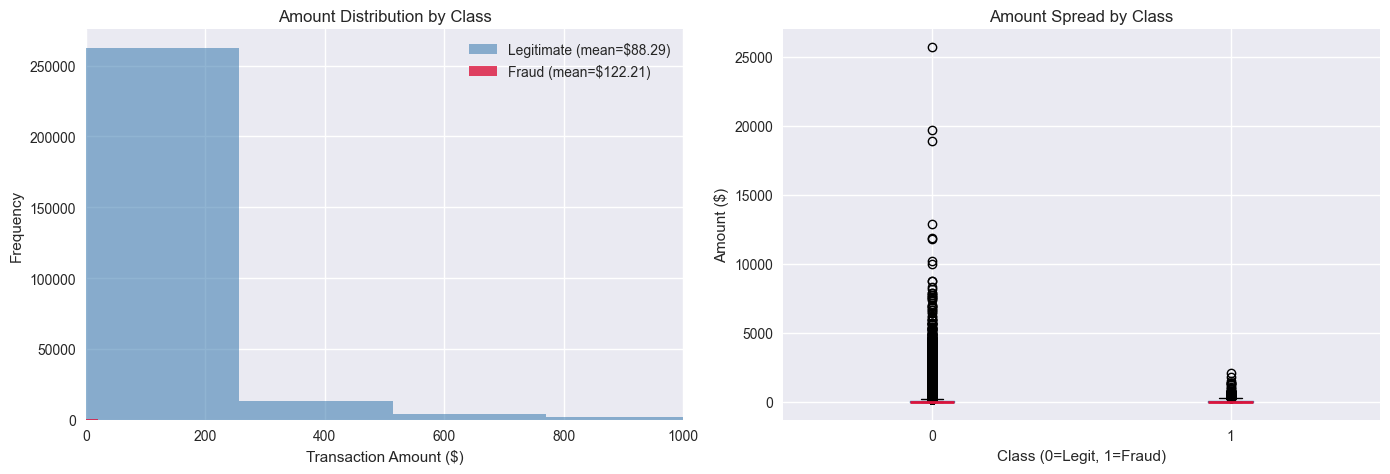

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

legit = df[df['Class'] == 0]['Amount']
fraud = df[df['Class'] == 1]['Amount']

# Distribution
axes[0].hist(legit, bins=100, alpha=0.6, color='steelblue', 
             label=f'Legitimate (mean=${legit.mean():.2f})')
axes[0].hist(fraud, bins=100, alpha=0.8, color='crimson',
             label=f'Fraud (mean=${fraud.mean():.2f})')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Amount Distribution by Class')
axes[0].set_xlim(0, 1000)  # cap at 1000 for visibility
axes[0].legend()

# Boxplot
df.boxplot(column='Amount', by='Class', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='crimson', linewidth=2))
axes[1].set_title('Amount Spread by Class')
axes[1].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[1].set_ylabel('Amount ($)')
plt.suptitle('')

print("=== AMOUNT STATISTICS ===")
print(df.groupby('Class')['Amount'].describe().round(2))

plt.tight_layout()
plt.savefig('../reports/02_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Peak fraud hours:
Hour
2.0000   1.7127
4.0000   1.0412
3.0000   0.4868
5.0000   0.3679
7.0000   0.3175
Name: FraudRate, dtype: float64


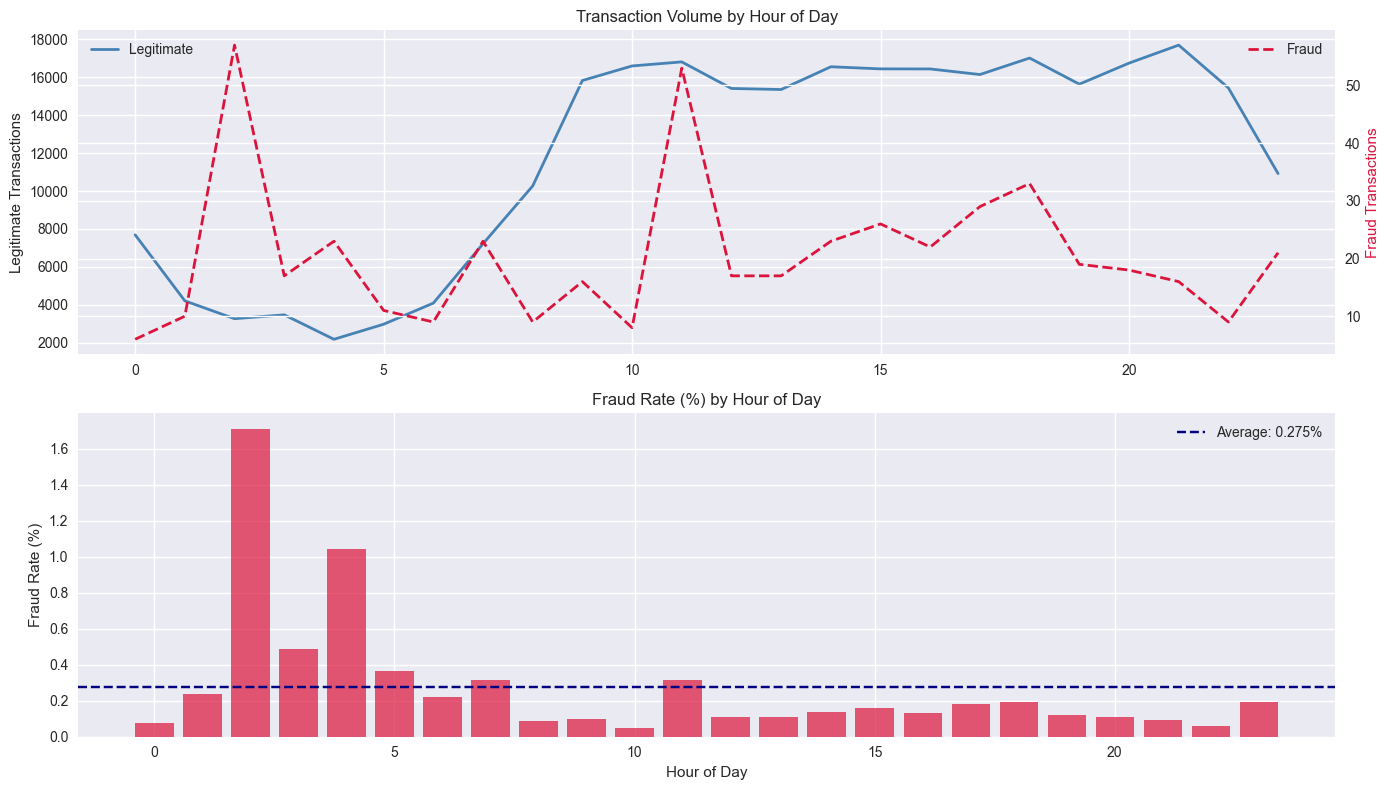

In [5]:
df['Hour'] = (df['Time'] // 3600) % 24

hourly = df.groupby(['Hour', 'Class']).size().unstack(fill_value=0)
hourly.columns = ['Legitimate', 'Fraud']

# Fraud rate by hour
hourly['FraudRate'] = hourly['Fraud'] / (hourly['Legitimate'] + hourly['Fraud']) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Volume by hour
axes[0].plot(hourly.index, hourly['Legitimate'], 
             color='steelblue', label='Legitimate', linewidth=2)
axes[0].set_ylabel('Legitimate Transactions')
axes[0].set_title('Transaction Volume by Hour of Day')
ax2 = axes[0].twinx()
ax2.plot(hourly.index, hourly['Fraud'], 
         color='crimson', label='Fraud', linewidth=2, linestyle='--')
ax2.set_ylabel('Fraud Transactions', color='crimson')
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

# Fraud rate by hour
axes[1].bar(hourly.index, hourly['FraudRate'], color='crimson', alpha=0.7)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate (%) by Hour of Day')
axes[1].axhline(y=hourly['FraudRate'].mean(), color='navy', 
                linestyle='--', label=f'Average: {hourly["FraudRate"].mean():.3f}%')
axes[1].legend()

print("Peak fraud hours:")
print(hourly['FraudRate'].nlargest(5))

plt.tight_layout()
plt.savefig('../reports/03_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

Top 10 most discriminative features:
V17   0.3265
V14   0.3025
V12   0.2606
V10   0.2169
V16   0.1965
V3    0.1930
V7    0.1873
V11   0.1549
V4    0.1334
V18   0.1115
Name: Class, dtype: float64


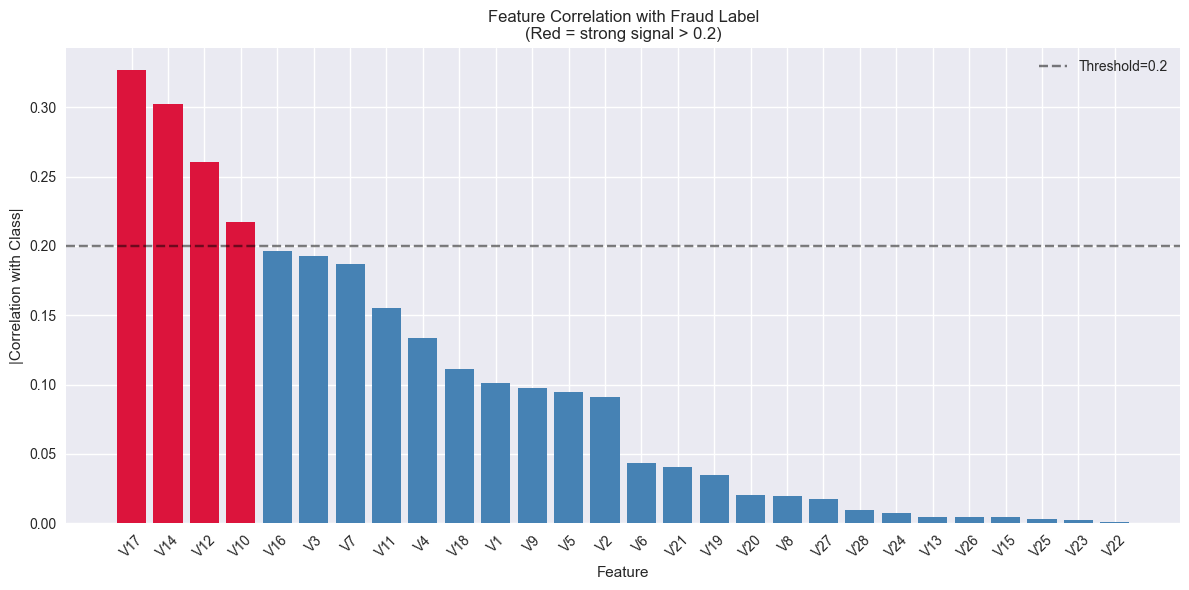

In [6]:
# Which V-features discriminate fraud best?
feature_cols = [c for c in df.columns if c.startswith('V')]

correlations = df[feature_cols + ['Class']].corr()['Class'].drop('Class').abs()
correlations_sorted = correlations.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['crimson' if v > 0.2 else 'steelblue' for v in correlations_sorted.values]
ax.bar(correlations_sorted.index, correlations_sorted.values, color=colors)
ax.set_xlabel('Feature')
ax.set_ylabel('|Correlation with Class|')
ax.set_title('Feature Correlation with Fraud Label\n(Red = strong signal > 0.2)')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=0.2, color='black', linestyle='--', alpha=0.5, label='Threshold=0.2')
ax.legend()

print("Top 10 most discriminative features:")
print(correlations_sorted.head(10))

plt.tight_layout()
plt.savefig('../reports/04_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print("=== DATA QUALITY REPORT ===\n")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum().sum()} total missing")

print(f"\nAmount outliers (> $5000): {(df['Amount'] > 5000).sum()}")
print(f"Amount outliers (> $10000): {(df['Amount'] > 10000).sum()}")
print(f"Max transaction amount: ${df['Amount'].max():,.2f}")

print(f"\nTime range: {df['Time'].min():.0f}s to {df['Time'].max():.0f}s")
print(f"= {df['Time'].max()/3600:.1f} hours of transaction data")

print(f"\nDuplicate rows: {df.duplicated().sum()}")

=== DATA QUALITY REPORT ===

Total rows: 284,807
Total columns: 32

Missing values:
0 total missing

Amount outliers (> $5000): 55
Amount outliers (> $10000): 7
Max transaction amount: $25,691.16

Time range: 0s to 172792s
= 48.0 hours of transaction data

Duplicate rows: 1081


In [9]:
# Remove duplicates before any modeling
print(f"Shape before: {df.shape}")
df = df.drop_duplicates()
print(f"Shape after:  {df.shape}")
print(f"Removed: {1081} duplicate rows")

# Verify fraud count is still intact
print(f"\nFraud cases remaining: {df['Class'].sum()}")
print(f"Fraud rate: {df['Class'].mean()*100:.3f}%")

Shape before: (284807, 32)
Shape after:  (283726, 32)
Removed: 1081 duplicate rows

Fraud cases remaining: 473
Fraud rate: 0.167%
